!pip install nats_bench

In [1]:
import os
import tarfile
from nats_bench import create

# ── PATH CONFIG ──────────────────────────────────────────────────────────
# Questo notebook sta in progetto-deeplearning/latent_space/
# I dataset stanno in progetto-deeplearning/datasets/
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

# Estrazione archivio (solo la prima volta)
if not os.path.exists(DATASET_PATH):
    print('Estrazione in corso...')
    with tarfile.open(percorso_tar, 'r') as tar:
        tar.extractall(path=DATASETS_DIR)
    print('Estrazione completata!')
else:
    print('Dataset già estratto.')

# Caricamento API NATS-Bench TSS
api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


In [2]:
import torch
import numpy as np
import random

seed = 42

# Python random
random.seed(seed)

# NumPy
np.random.seed(seed)

# PyTorch CPU
torch.manual_seed(seed)

# PyTorch GPU (se usi CUDA)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# per riproducibilità più forte (può rallentare)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## API inspection 

un elemento del dataset:
- DAG dell'architettura in cui ogni nodo è una cella di operazioni (conv, max pooling..)
- risultati su vari datasets e su regime brene e lungo di training 

In [3]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382 & top1 = 86.97%], valid : [loss = 0.514 & top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243 & top1 = 91.69%], test  : [loss = 0.362 & top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271 & top1 = 63.76%], valid : [loss = 1.495 & top1 = 57.80%], test : [loss = 1.478 & top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548 & top1 = 35.41%], valid : [loss = 2.580 & top1 = 35.43%], test : [loss = 2.611 & top1 = 33.80%]
>>>>>>>>

per vedere risultati su un datasets e una specifica architettura 

In [4]:
# Mostra info per un'architettura specifica
idx = 1

# Accuracy su cifar10
info_cifar10 = api.get_more_info(idx, 'cifar10', is_random=False)
print('cifar10  test-accuracy:', info_cifar10.get('test-accuracy'))

# Accuracy su cifar100
info_cifar100 = api.get_more_info(idx, 'cifar100', is_random=False)
print('cifar100 test-accuracy:', info_cifar100.get('test-accuracy'))


cifar10  test-accuracy: 88.22
cifar100 test-accuracy: 58.25999995727539


In [5]:
# Stringa architettura TSS: canali di ogni layer
print(api[0])


|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


In [6]:
import numpy as np
import re

OPS = {
    'nor_conv_3x3': 0,
    'nor_conv_1x1': 1,
    'skip_connect': 2,
    'avg_pool_3x3': 3,
    'none':         4,
    'zeroize':      5,
}

def arch_to_tensor(arch_str):
    """
    Converte una stringa NATS-Bench TSS / NAS-Bench-201
    (es. '|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+...')
    in un tensore A[op, src, dst] di shape (6, 4, 4).
    Flattened: 6*4*4 = 96 valori.
    """
    nodes = arch_str.strip('|').split('+')
    N = len(nodes) + 1  # nodi totali (input + intermedi)
    K = len(OPS)
    A = np.zeros((K, N, N), dtype=np.float32)
    for dst, node in enumerate(nodes, start=1):
        edges = re.findall(
            r'(' + '|'.join(OPS.keys()) + r')~(\d)',
            node
        )
        for op_name, src_node in edges:
            A[OPS[op_name], int(src_node), dst] = 1.0
    return A


In [7]:
arch_to_tensor(arch_str=api[0])


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]], dtype=float32)

In [8]:
all_tensors = []

for i in range(len(api)):
    arch_str = api[i]
    A = arch_to_tensor(arch_str)
    all_tensors.append(A)

X = np.stack(all_tensors)  # shape: (N_architetture, 6, 4, 4)
print('X shape:', X.shape)


X shape: (15625, 6, 4, 4)


In [9]:
import torch
X = torch.tensor(X)       # shape: (N_architetture, 6, 4, 4)
X = X.view(len(X), -1)    # flatten → (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


In [10]:
# Verifica shape: dovrebbe essere (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


# VAE implementation 

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

LATENT_DIM = 16
INPUT_DIM = 96


class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------
        # Encoder
        # --------------------
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)

        self.mu = nn.Linear(64, LATENT_DIM)
        self.logvar = nn.Linear(64, LATENT_DIM)

        # --------------------
        # Decoder
        # --------------------
        self.fc3 = nn.Linear(LATENT_DIM, 64)
        self.fc4 = nn.Linear(64, 128)
        self.fc5 = nn.Linear(128, INPUT_DIM)

        # --------------------
        # Predictor (accuracy head)
        # --------------------
        self.acc_predictor = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        return torch.sigmoid(self.fc5(h))

    def predict_acc(self, z):
        return self.acc_predictor(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        acc_pred = self.predict_acc(z)

        return recon, mu, logvar, acc_pred

- **vae_loss** prende in considerazione la reconstruction loss e la KL divergence 
- **vae_accuracy_loss** prende in considerazione anche la differenza tra l'accuracy predetta e quella attuale 

In [38]:
import torch.nn.functional as F

def vae_loss(recon, x, mu, logvar,beta=1):

    # ricostruzione
    recon_loss = F.binary_cross_entropy(
        recon,
        x,
        reduction='sum'
    )

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl * beta

def vae_accuracy_loss(
    recon,
    x,
    mu,
    logvar,
    pred_acc,
    true_acc,
    beta=1.0,
    lambda_acc=1.0
):

    recon_loss = F.mse_loss(recon, x)

    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    acc_loss = F.mse_loss(pred_acc.squeeze(), true_acc)

    loss = recon_loss + beta * kl + lambda_acc * acc_loss

    return loss, recon_loss, kl, acc_loss

## loading dataset


In [39]:

from torch.utils.data import TensorDataset, DataLoader, random_split

# estraendo le accuracy
y =[]
for idx in range(len(api)):
    info = api.get_more_info(
        idx,
        'cifar10',
        is_random=False
    )

    acc = info.get('test-accuracy')

    y.append(acc)

y = torch.tensor(y, dtype=torch.float32)
y = y / 100.0

dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


In [52]:
epochs = 50
DEVICE ="cuda" if torch.cuda.is_available() else "cpu"
model = VAE().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

lambda_acc = 1   # peso accuracy loss
beta = 1.2        # KL weight

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(DEVICE)
        y = batch[1].to(DEVICE)   # accuracy target

        # forward
        recon, mu, logvar, pred_acc = model(x)

        # --- TOTAL LOSS ---
        loss,_,_,_ = vae_accuracy_loss(recon,x,mu,logvar,pred_acc,y,beta=beta,lambda_acc = lambda_acc)
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 15.3914
Epoch 2 | Loss: 7.4230
Epoch 3 | Loss: 7.1041
Epoch 4 | Loss: 6.9622
Epoch 5 | Loss: 6.8562
Epoch 6 | Loss: 6.8095
Epoch 7 | Loss: 6.7716
Epoch 8 | Loss: 6.7497
Epoch 9 | Loss: 6.7215
Epoch 10 | Loss: 6.7262
Epoch 11 | Loss: 6.7056
Epoch 12 | Loss: 6.7092
Epoch 13 | Loss: 6.6919
Epoch 14 | Loss: 6.6962
Epoch 15 | Loss: 6.6905
Epoch 16 | Loss: 6.6874
Epoch 17 | Loss: 6.6835
Epoch 18 | Loss: 6.6797
Epoch 19 | Loss: 6.6835
Epoch 20 | Loss: 6.6780
Epoch 21 | Loss: 6.6738
Epoch 22 | Loss: 6.6705
Epoch 23 | Loss: 6.6674
Epoch 24 | Loss: 6.6693
Epoch 25 | Loss: 6.6649
Epoch 26 | Loss: 6.6711
Epoch 27 | Loss: 6.6672
Epoch 28 | Loss: 6.6642
Epoch 29 | Loss: 6.6664
Epoch 30 | Loss: 6.6572
Epoch 31 | Loss: 6.6622
Epoch 32 | Loss: 6.6686
Epoch 33 | Loss: 6.6651
Epoch 34 | Loss: 6.6635
Epoch 35 | Loss: 6.6525
Epoch 36 | Loss: 6.6583
Epoch 37 | Loss: 6.6523
Epoch 38 | Loss: 6.6491
Epoch 39 | Loss: 6.6559
Epoch 40 | Loss: 6.6587
Epoch 41 | Loss: 6.6584
Epoch 42 | Loss: 6.6609


In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])

with torch.no_grad():

    mu, logvar = model.encode(X_train)

    z = mu   # embedding stabile
z = z.numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d_vae_acc = pca.fit_transform(z)

In [54]:
print(z.shape)

(12500, 16)


## base VAE

In [112]:
epochs = 50
DEVICE ="cuda" if torch.cuda.is_available() else "cpu"
model = VAE().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

lambda_acc = 1   # peso accuracy loss
beta = 1.3        # KL weight

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(DEVICE)
        y = batch[1].to(DEVICE)   # accuracy target

        # forward
        recon, mu, logvar, pred_acc = model(x)

        # --- TOTAL LOSS ---
        loss = vae_loss(recon,x,mu,logvar,beta=beta)
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 329473.3439
Epoch 2 | Loss: 190524.6792
Epoch 3 | Loss: 189759.9220
Epoch 4 | Loss: 189413.8165
Epoch 5 | Loss: 189268.6251
Epoch 6 | Loss: 189131.0135
Epoch 7 | Loss: 189121.8704
Epoch 8 | Loss: 188850.8225
Epoch 9 | Loss: 188743.2554
Epoch 10 | Loss: 188653.2002
Epoch 11 | Loss: 188502.7772
Epoch 12 | Loss: 188434.1962
Epoch 13 | Loss: 188404.7493
Epoch 14 | Loss: 188284.8864
Epoch 15 | Loss: 188256.4635
Epoch 16 | Loss: 188226.5081
Epoch 17 | Loss: 188156.9542
Epoch 18 | Loss: 188115.0675
Epoch 19 | Loss: 188097.0314
Epoch 20 | Loss: 188082.9409
Epoch 21 | Loss: 188094.2097
Epoch 22 | Loss: 188099.0560
Epoch 23 | Loss: 188104.4647
Epoch 24 | Loss: 188016.9689
Epoch 25 | Loss: 188023.6888
Epoch 26 | Loss: 187970.2997
Epoch 27 | Loss: 188036.1426
Epoch 28 | Loss: 187988.2255
Epoch 29 | Loss: 187954.9353
Epoch 30 | Loss: 187960.3163
Epoch 31 | Loss: 187915.5302
Epoch 32 | Loss: 187918.6205
Epoch 33 | Loss: 187914.9353
Epoch 34 | Loss: 187844.6117
Epoch 35 | Loss: 187918

In [113]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])

with torch.no_grad():

    mu, logvar = model.encode(X_train)

    z = mu   # embedding stabile
z = z.numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d_vae = pca.fit_transform(z)


In [ ]:
print(y_train)

tensor([0.8713, 0.6052, 0.8467,  ..., 0.8505, 0.5902, 0.8388])


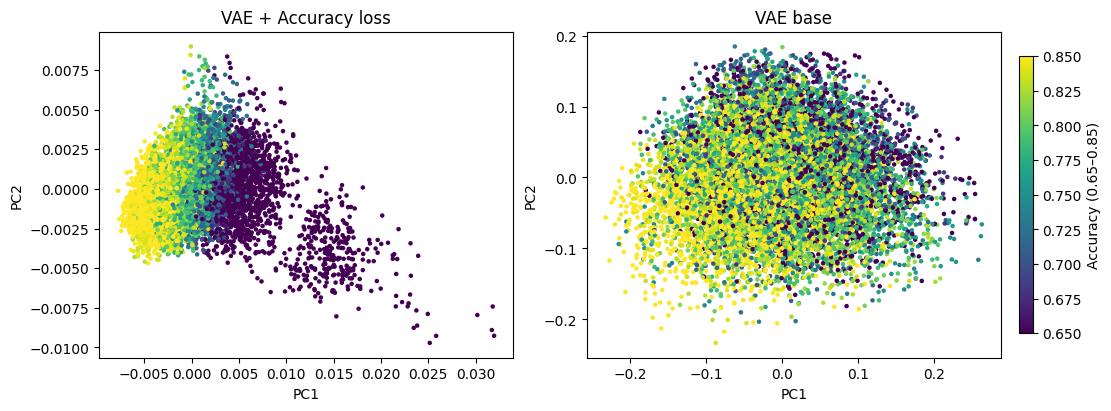

In [114]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

# ---------------------------
# VAE + accuracy loss
# ---------------------------
sc0 = axes[0].scatter(
    z_2d_vae_acc[:,0],
    z_2d_vae_acc[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)

axes[0].set_title("VAE + Accuracy loss")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# ---------------------------
# VAE base
# ---------------------------
sc1 = axes[1].scatter(
    z_2d_vae[:,0],
    z_2d_vae[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)

axes[1].set_title("VAE base")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# ---------------------------
# colorbar globale (FIX)
# ---------------------------
cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Accuracy (0.65–0.85)")

plt.show()

# Flow matching 

**per farlo funzionare runna le celle sopra tranne quelle del base VAE**

## high accuracy-low accuracy 

per fare i test:
1. divido le architetture in tre classi in base all'accuracy bassa-media-alta
2. uso flow matching per muovermi nello spazio latente prima da bassa-media e poi da media-alta

In [55]:
y_train_np = y_train.numpy()

In [56]:
y = y_train.numpy()
idx = np.argsort(y)

n = len(y)
k = n // 2

low_idx  = idx[:k]
high_idx  = idx[k:2*k]

low_mask = np.zeros(n, dtype=bool)
high_mask = np.zeros(n, dtype=bool)

low_mask[low_idx] = True
high_mask[high_idx] = True

In [57]:
print(z.shape)

(12500, 16)


In [58]:
z.shape
z_low = z[low_mask]
z_high = z[high_mask]

print(z_low.shape,z_high.shape)

(6250, 16) (6250, 16)


In [59]:
#rete neurale del flow matching mi serve per predirre la traiettora
class FlowNet(nn.Module):
    def __init__(self, dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, dim)
        )

    def forward(self, x):
        return self.net(x)

def flow_loss(model, x, y):
    target = y - x
    pred = model(x)
    return ((pred - target) ** 2).mean()

In [60]:
flow1 = FlowNet(dim=LATENT_DIM).to(DEVICE)
opt1 = torch.optim.Adam(flow1.parameters(), lr=1e-3)

for epoch in range(200):

    x = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(z_high, dtype=torch.float32).to(DEVICE)
    loss = flow_loss(flow1, x, y)

    opt1.zero_grad()
    loss.backward()
    opt1.step()

    if epoch % 20 == 0:
        print("flow1:", loss.item())

flow1: 0.0037869287189096212
flow1: 5.7614463003119454e-05
flow1: 1.603602504474111e-05
flow1: 3.4829386095225345e-06
flow1: 2.5824604108493077e-06
flow1: 2.359119662287412e-06
flow1: 2.3213119675347116e-06
flow1: 2.3042077827994945e-06
flow1: 2.287888264618232e-06
flow1: 2.2713113594363676e-06


In [61]:
# 1. Estrai z dal test set
X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
y_test_np = np.array([test_dataset[i][1] for i in range(len(test_dataset))])

with torch.no_grad():
    mu_test, _ = model.encode(X_test)

z_test_np = mu_test.cpu().numpy()

# 2. Prendi solo i punti "low" del test (stessa soglia: metà inferiore)
y_test_sorted = np.argsort(y_test_np)
k_test = len(y_test_np) // 2
low_idx_test = y_test_sorted[:k_test]

z_low_test = z_test_np[low_idx_test]

# 3. Applica il flow
z_low_test_tensor = torch.tensor(z_low_test, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    v_test = flow1(z_low_test_tensor)

v_test_np = v_test.cpu().numpy()

# 4. Proietta con la STESSA PCA fittata sul train
z_low_test_2d = pca.transform(z_low_test)
z_next_test_2d = pca.transform(z_low_test + v_test_np)
v_test_2d = z_next_test_2d - z_low_test_2d

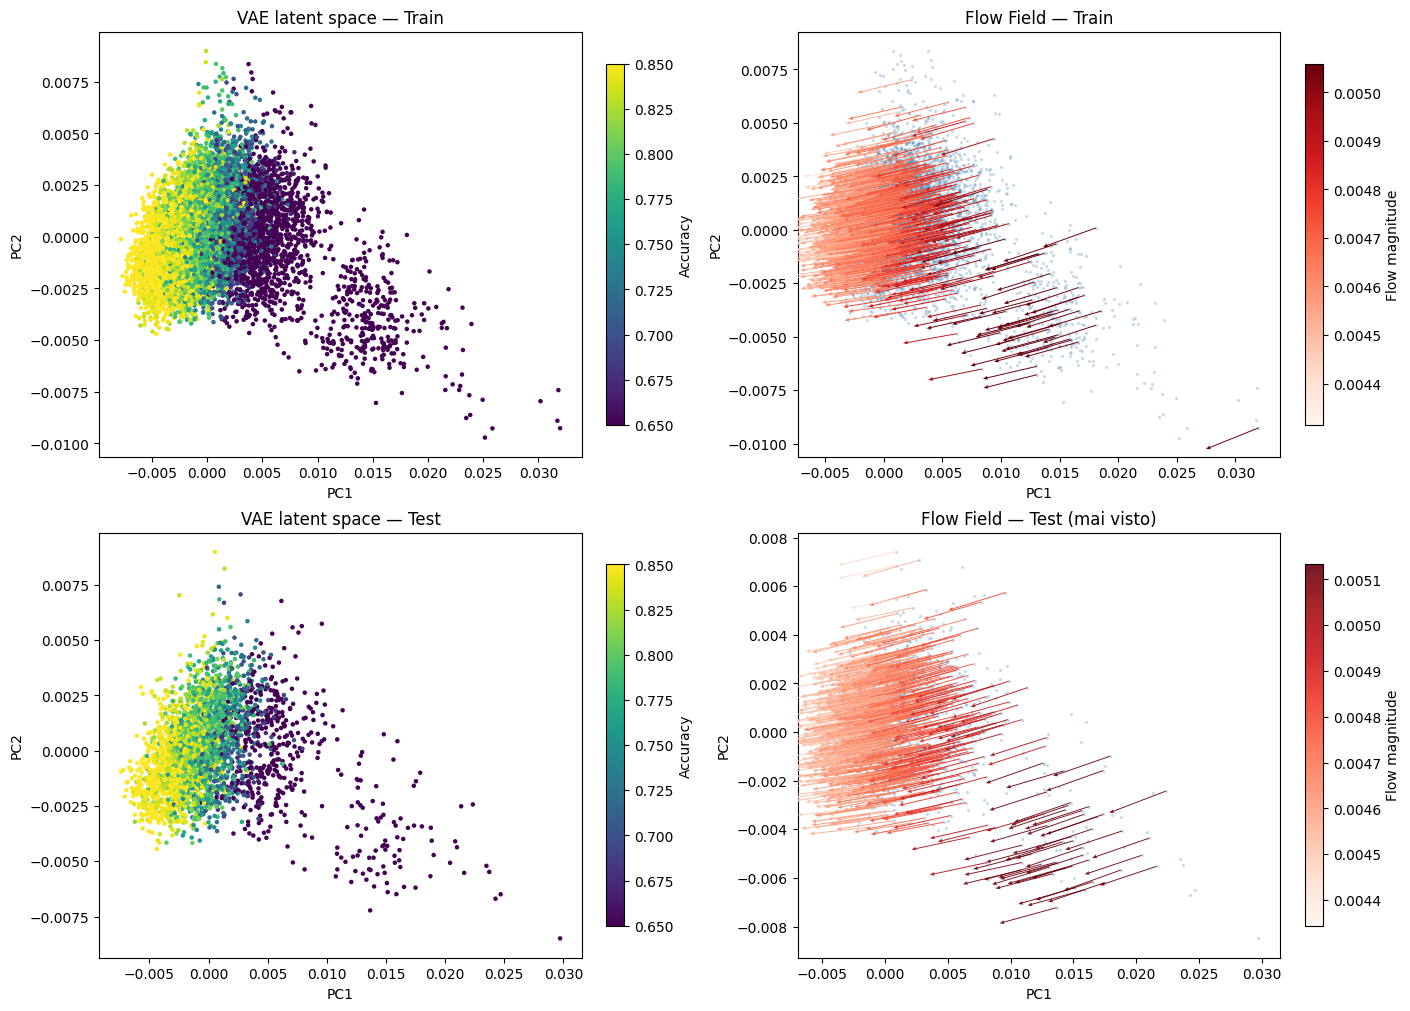

In [ ]:

# ============================================================
# 0. SETUP
# ============================================================
flow1.eval()

# ============================================================
# 1. LATENT SPACE (VAE)
# ============================================================
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])

with torch.no_grad():
    mu, logvar = model.encode(X_train)
    z_all = mu  # latent space completo

z_all_np = z_all.cpu().numpy()

# ============================================================
# 2. FIT PCA SU TUTTO LO SPAZIO (IMPORTANTISSIMO)
# ============================================================
pca = PCA(n_components=2)
pca.fit(z_all_np)

vae_2d = pca.transform(z_all_np)

# ============================================================
# 3. FLOW FIELD SU LOW SUBSET
# ============================================================
z_low_tensor = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    v = flow1(z_low_tensor)

z_low_np = z_low_tensor.cpu().numpy()
v_np = v.cpu().numpy()

# proiezione stabile
z_low_2d = pca.transform(z_low_np)
z_next_2d = pca.transform(z_low_np + v_np)

v_2d = z_next_2d - z_low_2d

# subsample per visualizzazione
idx = np.random.choice(len(z_low_2d), size=min(800, len(z_low_2d)), replace=False)



fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# ============================================================
# RIGA 0 — TRAIN
# ============================================================

# (0,0) VAE latent space — train
sc0 = axes[0,0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0,0].set_title("VAE latent space — Train")
axes[0,0].set_xlabel("PC1")
axes[0,0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0,0], shrink=0.85).set_label("Accuracy")

# (0,1) Flow field — train
v_mag = np.linalg.norm(v_2d, axis=1)
v_norm = v_2d / (v_mag[:, None] + 1e-8)
arrow_len = np.percentile(v_mag, 30)
idx = np.random.choice(len(z_low_2d), size=min(800, len(z_low_2d)), replace=False)

axes[0,1].scatter(z_low_2d[:,0], z_low_2d[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2)

q = axes[0,1].quiver(
    z_low_2d[idx,0], z_low_2d[idx,1],
    v_norm[idx,0] * arrow_len, v_norm[idx,1] * arrow_len,
    v_mag[idx], cmap="Reds",
    norm=plt.Normalize(vmin=v_mag.min(), vmax=np.percentile(v_mag, 95)),
    angles="xy", scale_units="xy", scale=1,
    width=0.002, headwidth=4, headlength=5, alpha=1, zorder=3
)
axes[0,1].set_title("Flow Field — Train")
axes[0,1].set_xlabel("PC1")
axes[0,1].set_ylabel("PC2")

fig.colorbar(q, ax=axes[0,1], shrink=0.85).set_label("Flow magnitude")

# ============================================================
# RIGA 1 — TEST
# ============================================================

# (1,0) VAE latent space — test
X_test_all = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
with torch.no_grad():
    mu_test_all, _ = model.encode(X_test_all)
vae_test_2d = pca.transform(mu_test_all.cpu().numpy())
y_test_np = np.array([test_dataset[i][1] for i in range(len(test_dataset))])

sc1 = axes[1,0].scatter(
    vae_test_2d[:,0], vae_test_2d[:,1],
    c=y_test_np, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[1,0].set_title("VAE latent space — Test")
axes[1,0].set_xlabel("PC1")
axes[1,0].set_ylabel("PC2")
fig.colorbar(sc1, ax=axes[1,0], shrink=0.85).set_label("Accuracy")

# (1,1) Flow field — test
v_mag_test = np.linalg.norm(v_test_2d, axis=1)
v_norm_test = v_test_2d / (v_mag_test[:, None] + 1e-8)
arrow_len_test = np.percentile(v_mag_test, 30)
idx_test = np.random.choice(len(z_low_test_2d), size=min(800, len(z_low_test_2d)), replace=False)

axes[1,1].scatter(z_low_test_2d[:,0], z_low_test_2d[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2)

q_test = axes[1,1].quiver(
    z_low_test_2d[idx_test,0], z_low_test_2d[idx_test,1],
    v_norm_test[idx_test,0] * arrow_len_test, v_norm_test[idx_test,1] * arrow_len_test,
    v_mag_test[idx_test], cmap="Reds",
    norm=plt.Normalize(vmin=v_mag_test.min(), vmax=np.percentile(v_mag_test, 95)),
    angles="xy", scale_units="xy", scale=1,
    width=0.002, headwidth=4, headlength=5, alpha=0.9, zorder=3
)
axes[1,1].set_title("Flow Field — Test (mai visto)")
axes[1,1].set_xlabel("PC1")
axes[1,1].set_ylabel("PC2")

fig.colorbar(q_test, ax=axes[1,1], shrink=0.85).set_label("Flow magnitude")

plt.show()

## pairwise for continuous learning 

In [75]:
z_all_np = z_all.cpu().numpy()
y_train_np = y_train.numpy()


- in pratica per ogni punto prendo randomicamente un vicino con accuracy migliore tra i K più vicini

In [76]:
from sklearn.neighbors import NearestNeighbors


K = 50   # vicini locali


nbrs = NearestNeighbors(
    n_neighbors=K
).fit(z_all_np)

distances, indices = nbrs.kneighbors(z_all_np)


pairs_x = []
pairs_target = []

for i in range(len(z_all_np)):

    z_i = z_all_np[i]
    acc_i = y_train_np[i]

    neigh_idx = indices[i]

    # vicini migliori
    better = []

    for j in neigh_idx:

        if y_train_np[j] > acc_i:

            better.append(j)

    if len(better) == 0:
        continue

    # scegli random vicino migliore
    j = np.random.choice(better)

    z_j = z_all_np[j]

    direction = z_j - z_i

    pairs_x.append(z_i)
    pairs_target.append(direction)

pairs_x = torch.tensor(
    np.array(pairs_x),
    dtype=torch.float32
)

pairs_target = torch.tensor(
    np.array(pairs_target),
    dtype=torch.float32
)

print(pairs_x.shape)
print(pairs_target.shape)

torch.Size([12220, 16])
torch.Size([12220, 16])


In [77]:
import torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

flow = FlowNet(dim=LATENT_DIM).to(DEVICE)

optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)

pairs_x = pairs_x.to(DEVICE)
pairs_target = pairs_target.to(DEVICE)

epochs = 300

for epoch in range(epochs):

    pred = flow(pairs_x)

    loss = ((pred - pairs_target) ** 2).mean()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} | Loss {loss.item():.6f}"
        )

Epoch 0 | Loss 0.005405
Epoch 20 | Loss 0.000168
Epoch 40 | Loss 0.000017
Epoch 60 | Loss 0.000003
Epoch 80 | Loss 0.000000
Epoch 100 | Loss 0.000000
Epoch 120 | Loss 0.000000
Epoch 140 | Loss 0.000000
Epoch 160 | Loss 0.000000
Epoch 180 | Loss 0.000000
Epoch 200 | Loss 0.000000
Epoch 220 | Loss 0.000000
Epoch 240 | Loss 0.000000
Epoch 260 | Loss 0.000000
Epoch 280 | Loss 0.000000


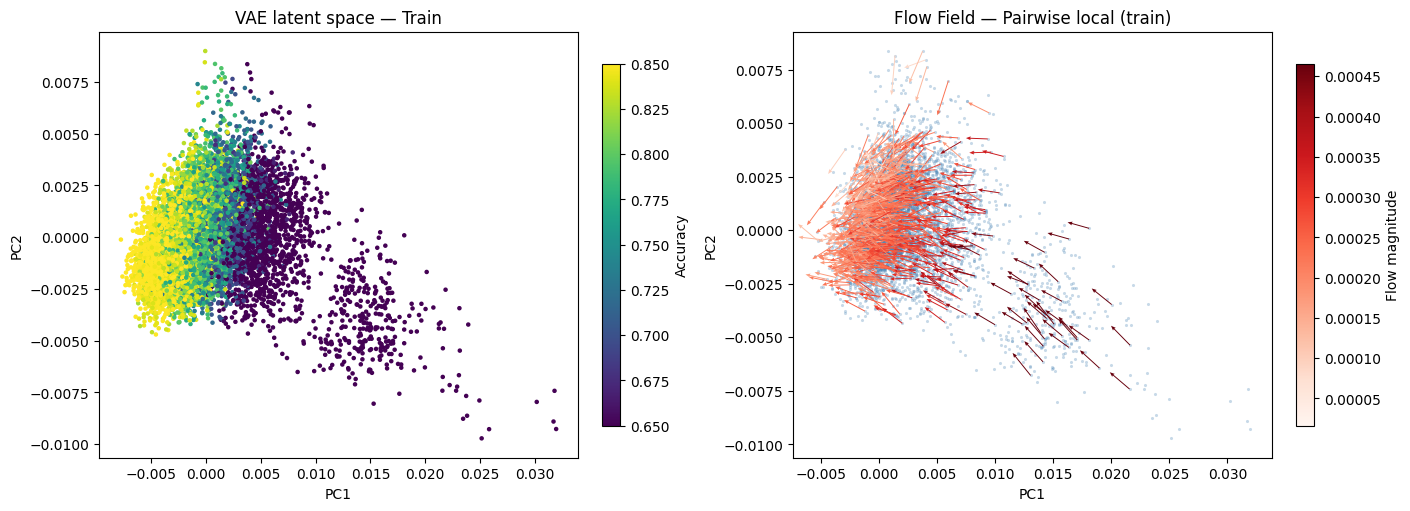

In [80]:
flow.eval()

with torch.no_grad():
    v_new = flow(torch.tensor(z_low, dtype=torch.float32).to(DEVICE))

v_new_np = v_new.cpu().numpy()

z_low_2d_new  = pca.transform(z_low)
z_next_2d_new = pca.transform(z_low + v_new_np)
v_2d_new      = z_next_2d_new - z_low_2d_new

v_mag_new  = np.linalg.norm(v_2d_new, axis=1)
v_norm_new = v_2d_new / (v_mag_new[:, None] + 1e-8)
# Con questa
x_range = z_low_2d_new[:,0].max() - z_low_2d_new[:,0].min()
arrow_len_new = x_range * 0.05  # 5% della larghezza del plot
idx_new = np.random.choice(len(z_low_2d_new), size=min(800, len(z_low_2d_new)), replace=False)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Flow field — pairwise local
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

q_new = axes[1].quiver(
    z_low_2d_new[idx_new,0], z_low_2d_new[idx_new,1],
    v_norm_new[idx_new,0] * arrow_len_new,
    v_norm_new[idx_new,1] * arrow_len_new,
    v_mag_new[idx_new], cmap="Reds",
    norm=plt.Normalize(vmin=v_mag_new.min(), vmax=np.percentile(v_mag_new, 95)),
    angles="xy", scale_units="xy", scale=1,
    width=0.002, headwidth=4, headlength=5, alpha=1, zorder=3
)
axes[1].set_title("Flow Field — Pairwise local (train)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(q_new, ax=axes[1], shrink=0.85).set_label("Flow magnitude")

plt.show()

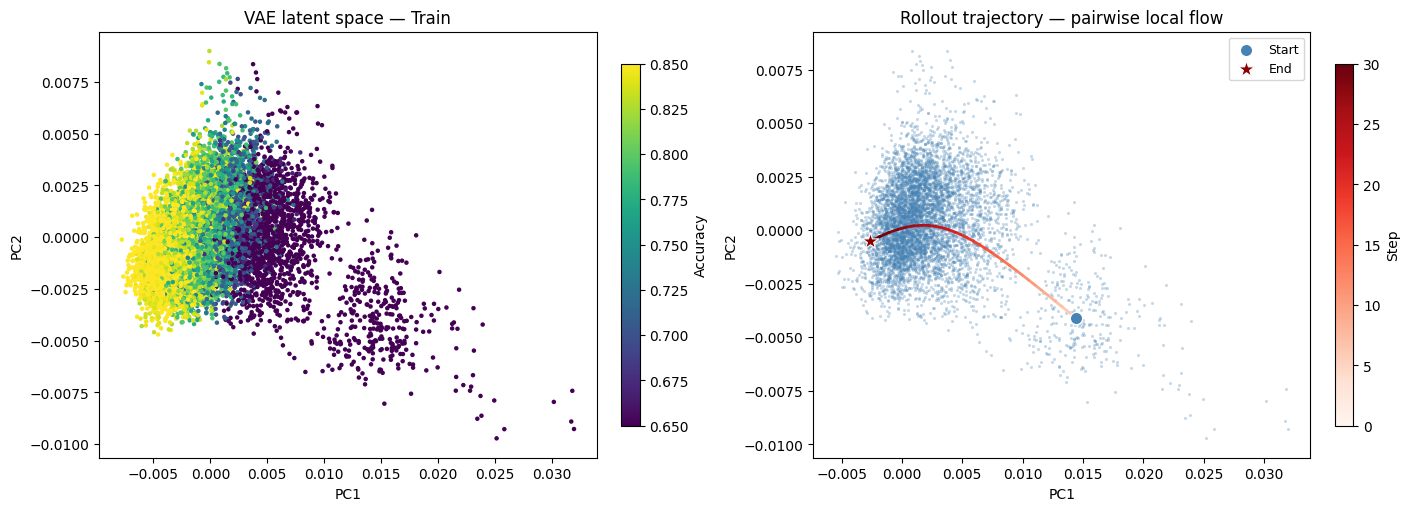

In [104]:
# ============================================================
# ROLLOUT — traiettoria multi-step
# ============================================================
start_idx = np.argmin(y_train.numpy())
z_start = z_all_np[start_idx:start_idx+1]

n_steps = 30
step_size = 1.3
trajectory = [z_start.copy()]

flow.eval()
z_current = z_start.copy()

with torch.no_grad():
    for _ in range(n_steps):
        z_tensor = torch.tensor(z_current, dtype=torch.float32).to(DEVICE)
        v = flow(z_tensor).cpu().numpy()
        z_current = z_current + step_size * v
        trajectory.append(z_current.copy())

trajectory = np.vstack(trajectory)
traj_2d = pca.transform(trajectory)

# ============================================================
# PLOT — stesso stile del flow field
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Traiettoria
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

# Linea colorata per step con cmap="Reds"
n = len(traj_2d)
cmap_traj = plt.cm.Reds
norm_traj = plt.Normalize(0, n_steps)
for i in range(n - 1):
    t = (i + 1) / n_steps
    axes[1].plot(
        traj_2d[i:i+2, 0], traj_2d[i:i+2, 1],
        color=cmap_traj(t * 0.85 + 0.15),  # evita il bianco iniziale
        linewidth=2, solid_capstyle="round", zorder=3
    )

# Start e End
axes[1].scatter(*traj_2d[0],  s=80, color="steelblue",
    zorder=5, edgecolors="white", linewidths=1, label="Start")
axes[1].scatter(*traj_2d[-1], s=150, marker="*", color="darkred",
    zorder=5, edgecolors="white", linewidths=0.8, label="End")

sm = plt.cm.ScalarMappable(cmap=cmap_traj, norm=norm_traj)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], shrink=0.85).set_label("Step")

axes[1].set_title("Rollout trajectory — pairwise local flow")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=9, framealpha=0.8, edgecolor="#ccc")

plt.show()